# 1D Heat Equation with PyTorch

We solve the one-dimensional heat equation

$$ u_t = \alpha u_{xx}
$$

on the spatial domain

$$
0 < x < L  \quad  0 < t  < 0.1
$$

with zero boundary conditions

$$
u(0,t) = 0, \qquad u(L,t) = 0
$$

and initial condition

$$
u(x,0) = \sin\left(\frac{\pi x}{L}\right).
$$

In [3]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Problem setting

We solve

$$
u_t = \alpha u_{xx} 
$$


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

alpha = 1.0
L     = 1.0
T     = 0.1
Nx    = 51
dx    = L / (Nx - 1)

x = torch.linspace(0, L, Nx, device=device)

# Stability condition for explicit FDM:
r  = 0.4  # r = alpha * dt / dx^2 <= 1/2
dt = r * dx**2 / alpha
Nt = int(T / dt)

dt = T / Nt
r  = alpha * dt / dx**2

print("device:", device)
print("dx =", dx)
print("dt =", dt)
print("r =", r)


# set x_grid
x_cpu = x.detach().cpu().numpy()


device: cuda
dx = 0.02
dt = 0.00016
r = 0.4


$$
u(x,0) = \sin\left(\frac{\pi x}{L}\right)
$$

In [5]:
# -----------------------
# Domain and PDE parameter
# -----------------------
T = 1.0
L = 1.0
x_min, x_max = 0, L

nu = 1
print("nu =", nu)


def initial_condition(x):
    return torch.sin(np.pi * x / L)

    

nu = 1


## Neural network model

The PINN represents the unknown solution as

$$
u(t,x)\approx u_\theta(t,x).
$$

The input is the pair \((t,x)\), and the output is the scalar value \(u(t,x)\).

In [6]:

class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden_layers=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, tx):
        return self.net(tx)


model = MLP(hidden_dim=64, num_hidden_layers=4).to(device)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## Automatic differentiation for the PDE residual

The Burgers residual is

$$
r_\theta(t,x)
=
u_t - \alpha u_{xx}
$$

Using PyTorch automatic differentiation, we compute

$$
\partial_t u_\theta,\qquad
\partial_x u_\theta,\qquad
\partial_{xx}u_\theta.
$$

In [8]:
def pdf_residual(model, tx, nu):
    """
    tx: tensor of shape (N, 2), where tx[:,0] = t and tx[:,1] = x
    """
    tx = tx.clone().detach().requires_grad_(True)

    u = model(tx)

    grad_u = torch.autograd.grad(
        u,
        tx,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_t = grad_u[:, 0:1]
    u_x = grad_u[:, 1:2]

    grad_u_x = torch.autograd.grad(
        u_x,
        tx,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    u_xx = grad_u_x[:, 1:2]

    residual = u_t  - nu * u_xx
    return residual

## Training points

We sample three kinds of points:

1. initial-condition points:
\[
(t,x)=(0,x),
\]

2. boundary-condition points:
\[
(t,x)=(t,-1),\quad (t,1),
\]

3. collocation points inside the domain:
\[
(t,x)\in(0,T)\times(-1,1).
\]

In [9]:
x_min,x_max

(0, 1.0)

In [14]:
# -----------------------
# Sampling training points
# -----------------------
N_ic = 256
N_bc = 256
N_f = 5000

# Initial condition points: t = 0
x_ic = torch.linspace(x_min, x_max, N_ic).view(-1, 1).to(device)
t_ic = torch.zeros_like(x_ic).to(device)
tx_ic = torch.cat([t_ic, x_ic], dim=1)
u_ic = initial_condition(x_ic).to(device)


In [15]:
t_bc = torch.rand(N_bc, 1).to(device) * T

x_left = torch.full_like(t_bc, x_min).to(device)
x_right = torch.full_like(t_bc, x_max).to(device) # Boundary condition points: x = 0 and x = 1

# x_left = torch.full_like(t_bc, x_min).to(device)
# x_right = torch.full_like(t_bc, x_max).to(device)



In [16]:
# Boundary condition points: x = 0 and x = 1
t_bc = torch.rand(N_bc, 1).to(device) * T

x_left = torch.full_like(t_bc, x_min).to(device)
x_right = torch.full_like(t_bc, x_max).to(device)

tx_bc_left = torch.cat([t_bc, x_left], dim=1)
tx_bc_right = torch.cat([t_bc, x_right], dim=1)

u_bc_left = torch.zeros_like(t_bc).to(device)
u_bc_right = torch.zeros_like(t_bc).to(device)

# PDE collocation points
t_f = torch.rand(N_f, 1).to(device) * T
x_f = x_min + (x_max - x_min) * torch.rand(N_f, 1).to(device)
tx_f = torch.cat([t_f, x_f], dim=1)

print("tx_ic:", tx_ic.shape)
print("tx_bc_left:", tx_bc_left.shape)
print("tx_f:", tx_f.shape)

tx_ic: torch.Size([256, 2])
tx_bc_left: torch.Size([256, 2])
tx_f: torch.Size([5000, 2])


In [17]:
# # Boundary condition points: x = -1 and x = 1
# t_bc = torch.rand(N_bc, 1).to(device) * T

# x_left = torch.full_like(t_bc, x_min).to(device)
# x_right = torch.full_like(t_bc, x_max).to(device)

# tx_bc_left = torch.cat([t_bc, x_left], dim=1)
# tx_bc_right = torch.cat([t_bc, x_right], dim=1)

# u_bc_left = torch.zeros_like(t_bc).to(device)
# u_bc_right = torch.zeros_like(t_bc).to(device)

# # PDE collocation points
# t_f = torch.rand(N_f, 1).to(device) * T
# x_f = x_min + (x_max - x_min) * torch.rand(N_f, 1).to(device)
# tx_f = torch.cat([t_f, x_f], dim=1)

# print("tx_ic:", tx_ic.shape)
# print("tx_bc_left:", tx_bc_left.shape)
# print("tx_f:", tx_f.shape)

## PINN training

The loss is

$$
\mathcal{L}_{IC}
=
\frac{1}{N_{IC}}\sum_i
\left|u_\theta(0,x_i)-u(0,x_i)\right|^2,
$$

$$
\mathcal{L}_{BC}
=
\frac{1}{N_{BC}}\sum_i
\left(
\left|u_\theta(t_i,-1)\right|^2
+
\left|u_\theta(t_i,1)\right|^2
\right),
$$

and

$$
\mathcal{L}_{PDE}
=
\frac{1}{N_f}\sum_i
\left|r_\theta(t_i,x_i)\right|^2.
$$

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

num_epochs = 5000
print_every = 500

loss_history = []
loss_ic_history = []
loss_bc_history = []
loss_pde_history = []

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()

    # Initial condition loss
    u_pred_ic = model(tx_ic)
    loss_ic = torch.mean((u_pred_ic - u_ic) ** 2)

    # Boundary condition loss
    u_pred_left = model(tx_bc_left)
    u_pred_right = model(tx_bc_right)
    loss_bc = torch.mean((u_pred_left - u_bc_left) ** 2) + torch.mean((u_pred_right - u_bc_right) ** 2)

    # PDE residual loss
    residual = pdf_residual(model, tx_f, nu)
    loss_pde = torch.mean(residual ** 2)

    loss = loss_ic + loss_bc + loss_pde
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    loss_ic_history.append(loss_ic.item())
    loss_bc_history.append(loss_bc.item())
    loss_pde_history.append(loss_pde.item())

    if epoch % print_every == 0 or epoch == 1:
        print(
            f"epoch {epoch:5d} | "
            f"loss={loss.item():.4e} | "
            f"IC={loss_ic.item():.4e} | "
            f"BC={loss_bc.item():.4e} | "
            f"PDE={loss_pde.item():.4e}"
        )

/home/yohan/miniconda3/envs/myenv_dl/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


epoch     1 | loss=6.9971e-01 | IC=6.4523e-01 | BC=4.7044e-02 | PDE=7.4403e-03
epoch   500 | loss=2.1459e-02 | IC=1.0853e-02 | BC=6.4858e-03 | PDE=4.1204e-03
epoch  1000 | loss=4.2088e-03 | IC=1.3145e-03 | BC=8.7284e-04 | PDE=2.0215e-03
epoch  1500 | loss=1.2525e-03 | IC=2.0950e-04 | BC=2.0104e-04 | PDE=8.4197e-04
epoch  2000 | loss=5.6189e-04 | IC=6.0653e-05 | BC=8.6985e-05 | PDE=4.1425e-04
epoch  2500 | loss=9.6798e-04 | IC=1.6763e-04 | BC=4.2781e-04 | PDE=3.7254e-04
epoch  3000 | loss=4.2699e-04 | IC=5.6974e-05 | BC=4.7878e-05 | PDE=3.2213e-04
epoch  3500 | loss=1.6276e-03 | IC=5.2832e-04 | BC=2.1207e-04 | PDE=8.8725e-04
epoch  4000 | loss=1.5062e-04 | IC=3.9148e-06 | BC=1.5182e-05 | PDE=1.3152e-04
epoch  4500 | loss=1.8701e-04 | IC=1.0291e-05 | BC=4.1921e-05 | PDE=1.3480e-04
epoch  5000 | loss=7.5810e-05 | IC=2.1564e-06 | BC=5.8514e-06 | PDE=6.7802e-05


## Visualize the training loss

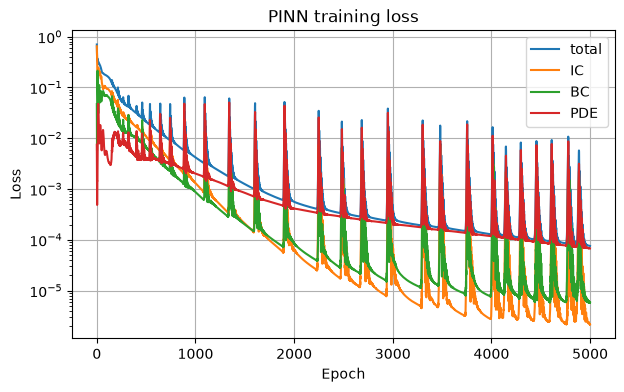

In [19]:
plt.figure(figsize=(7, 4))
plt.semilogy(loss_history, label="total")
plt.semilogy(loss_ic_history, label="IC")
plt.semilogy(loss_bc_history, label="BC")
plt.semilogy(loss_pde_history, label="PDE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN training loss")
plt.legend()
plt.grid(True)
plt.show()

## Predict the solution on a grid

In [20]:
# -----------------------
# Prediction grid
# -----------------------
Nx_plot = 256
Nt_plot = 101

x_plot = torch.linspace(x_min, x_max, Nx_plot).view(-1, 1).to(device)
t_plot = torch.linspace(0.0, T, Nt_plot).view(-1, 1).to(device)

TT, XX = torch.meshgrid(
    t_plot.squeeze(),
    x_plot.squeeze(),
    indexing="ij"
)

tx_grid = torch.stack([TT.reshape(-1), XX.reshape(-1)], dim=1)

model.eval()
with torch.no_grad():
    u_pred = model(tx_grid).reshape(Nt_plot, Nx_plot)

u_pred_np = u_pred.detach().cpu().numpy()
x_np = x_plot.detach().cpu().numpy().squeeze()
t_np = t_plot.detach().cpu().numpy().squeeze()

print("u_pred shape:", u_pred_np.shape)

u_pred shape: (101, 256)


## Contour plot of the PINN solution

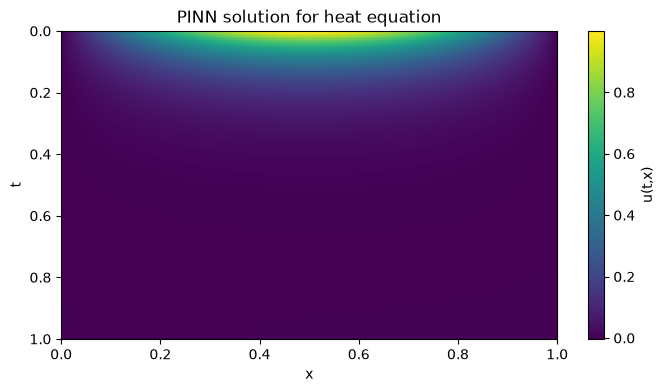

In [21]:
plt.figure(figsize=(8, 4))
plt.imshow(
    u_pred_np,
    extent=[x_min, x_max, T, 0],
    aspect="auto"
)
plt.colorbar(label="u(t,x)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN solution for heat equation")
plt.show()

## Snapshot plots

We visualize the learned solution at several time points.

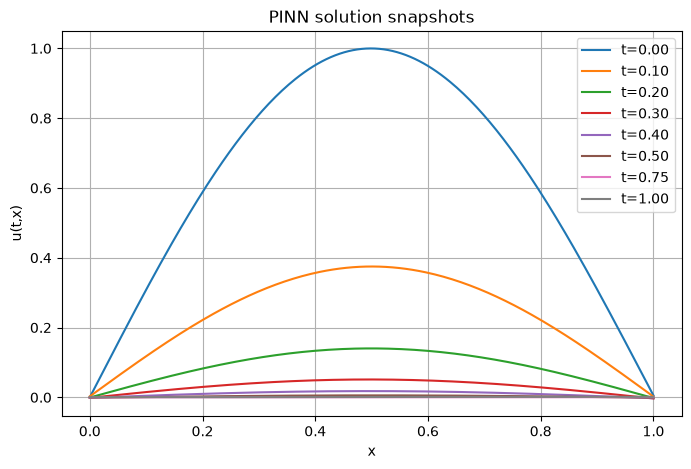

In [24]:
times_to_plot = [0.0, 0.1, 0.2,0.3,0.4, 0.50, 0.75, 1.0]
#t_history = torch.linspace(0, T, 6)  # 6 snapshots from 0 to T
    
plt.figure(figsize=(8, 5))

for t_now in times_to_plot:
    idx = np.argmin(np.abs(t_np - t_now))
    plt.plot(x_np, u_pred_np[idx, :], label=f"t={t_np[idx]:.2f}")

plt.xlabel("x")
plt.ylabel("u(t,x)")
plt.title("PINN solution snapshots")
plt.legend()
plt.grid(True)
plt.show()

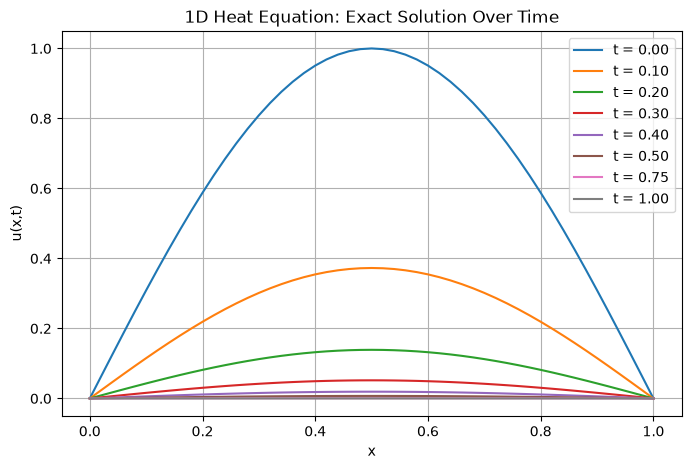

In [27]:

def exact_1d(x, t):
    return torch.exp(
        torch.tensor(-nu * (torch.pi / L)**2 * t, device=device)
    ) * torch.sin(torch.pi * x / L)
    
    

# choose several time points
#t_history = torch.linspace(0, T, 6)  # 6 snapshots from 0 to T


plt.figure(figsize=(8, 5))

for t in times_to_plot :
    u_exact     = exact_1d(x, t)
    u_exact_cpu = u_exact.detach().cpu().numpy()

    plt.plot(x_cpu, u_exact_cpu, label=f"t = {t:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D Heat Equation: Exact Solution Over Time")
plt.legend()
plt.grid(True)
plt.show()



## Remark

This PINN solves the Heat equation without using an exact solution.

However, Heat equation can develop steep gradients.
For better accuracy, you may increase:

- `num_epochs`,
- `N_f`,
- `hidden_dim`,
- or add an L-BFGS optimizer after Adam.